In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

from statsmodels.tsa.stattools import adfuller, kpss, ccf as sm_ccf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10})

In [2]:
df = pd.read_csv("C:/Users/kerem/Desktop/elektrikveri/claude/birlesik_veri.csv")
veri = df.copy()

In [3]:
veri["Datetime"] = pd.to_datetime(veri["Datetime"])
veri = veri.set_index("Datetime")
veri = veri.sort_index()

In [4]:
print("Duplicate sayısı:", veri.index.duplicated().sum())

veri = veri[~veri.index.duplicated()]

Duplicate sayısı: 0


In [5]:
print(veri.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 43824 entries, 2021-01-01 00:00:00 to 2025-12-31 23:00:00
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   uretim_mwh           43824 non-null  float64
 1   tuketim_mwh          43824 non-null  float64
 2   fiyat_tl             43824 non-null  float64
 3   sicaklik             43824 non-null  float64
 4   hissedilen_sicaklik  43824 non-null  float64
 5   nem                  43824 non-null  float64
 6   bulut_ortus          43824 non-null  float64
 7   ruzgar_hizi          43824 non-null  float64
 8   yagis                43824 non-null  float64
 9   saat                 43824 non-null  int64  
 10  haftanin_gunu        43824 non-null  int64  
 11  ay                   43824 non-null  int64  
 12  is_weekend           43824 non-null  int64  
 13  is_holiday           43824 non-null  int64  
dtypes: float64(9), int64(5)
memory usage: 5.0 MB
None


In [6]:
print(veri.head())

                     uretim_mwh  tuketim_mwh  fiyat_tl  sicaklik  \
Datetime                                                           
2021-01-01 00:00:00    29488.11     29489.46    259.39      9.79   
2021-01-01 01:00:00    28065.76     28067.11    234.13      9.88   
2021-01-01 02:00:00    26527.08     26527.08    215.25      9.58   
2021-01-01 03:00:00    25327.19     25327.19    219.24      9.55   
2021-01-01 04:00:00    24719.72     24719.72    209.81      9.32   

                     hissedilen_sicaklik    nem  bulut_ortus  ruzgar_hizi  \
Datetime                                                                    
2021-01-01 00:00:00                 6.91  77.41        59.42        13.50   
2021-01-01 01:00:00                 6.58  75.14        34.92        15.98   
2021-01-01 02:00:00                 6.37  77.43        37.49        15.81   
2021-01-01 03:00:00                 6.26  78.35        41.92        16.13   
2021-01-01 04:00:00                 6.26  79.02        36.95 

In [7]:
print("Veri boyutu:", veri.shape)

print("\nTemel istatistikler")
print(veri.describe())

print("\nVeri tipleri")
print(veri.dtypes)

Veri boyutu: (43824, 14)

Temel istatistikler
         uretim_mwh   tuketim_mwh      fiyat_tl      sicaklik  \
count  43824.000000  43824.000000  43824.000000  43824.000000   
mean   36029.874233  38109.804625   1993.135537     15.772203   
std     5759.315717   6197.273359   1090.175645      8.250155   
min    11175.310000  19209.200000      0.740000     -5.680000   
25%    31852.377500  33159.210000   1107.820000      9.240000   
50%    35887.015000  38256.175000   2131.720000     15.220000   
75%    39974.977500  42236.972500   2734.610000     22.170000   
max    56219.060000  59503.670000   4905.500000     38.420000   

       hissedilen_sicaklik           nem   bulut_ortus   ruzgar_hizi  \
count         43824.000000  43824.000000  43824.000000  43824.000000   
mean             14.251764     67.141223     42.503176     11.531905   
std               9.694545     15.415055     31.607500      4.610402   
min              -9.730000     14.990000      0.000000      1.360000   
25%     

In [8]:
print(veri.isnull().sum())

uretim_mwh             0
tuketim_mwh            0
fiyat_tl               0
sicaklik               0
hissedilen_sicaklik    0
nem                    0
bulut_ortus            0
ruzgar_hizi            0
yagis                  0
saat                   0
haftanin_gunu          0
ay                     0
is_weekend             0
is_holiday             0
dtype: int64


In [9]:
veri["fiyat_tl"] = veri["fiyat_tl"].interpolate(method="time")

In [10]:
print(veri.isnull().sum())

uretim_mwh             0
tuketim_mwh            0
fiyat_tl               0
sicaklik               0
hissedilen_sicaklik    0
nem                    0
bulut_ortus            0
ruzgar_hizi            0
yagis                  0
saat                   0
haftanin_gunu          0
ay                     0
is_weekend             0
is_holiday             0
dtype: int64


In [11]:
veri.to_csv("birlesik_veri.csv", index_label="Datetime",
            index=True, encoding="utf-8-sig")
veri.head()

,uretim_mwh,tuketim_mwh,fiyat_tl,sicaklik,hissedilen_sicaklik,nem,bulut_ortus,ruzgar_hizi,yagis,saat,haftanin_gunu,ay,is_weekend,is_holiday
Datetime,,,,,,,,,,,,,,
2021-01-01 00:00:00,29488.11,29489.46,259.39,9.79,6.91,77.41,59.42,13.50,0.01,0,4,1,0,1
2021-01-01 01:00:00,28065.76,28067.11,234.13,9.88,6.58,75.14,34.92,15.98,0.01,1,4,1,0,1
2021-01-01 02:00:00,26527.08,26527.08,215.25,9.58,6.37,77.43,37.49,15.81,0.01,2,4,1,0,1
2021-01-01 03:00:00,25327.19,25327.19,219.24,9.55,6.26,78.35,41.92,16.13,0.01,3,4,1,0,1
2021-01-01 04:00:00,24719.72,24719.72,209.81,9.32,6.26,79.02,36.95,14.82,0.06,4,4,1,0,1


**Görselleştirmeler**

Elektrik tüketimi

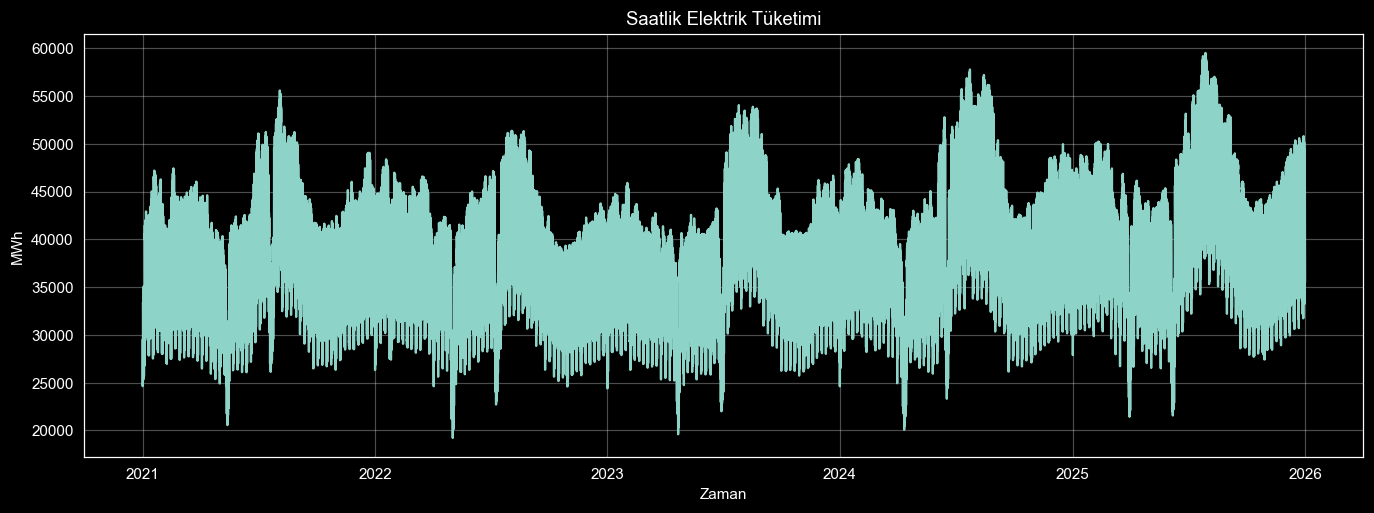

In [12]:
plt.figure(figsize=(15,5))

plt.plot(veri["tuketim_mwh"])

plt.title("Saatlik Elektrik Tüketimi")

plt.xlabel("Zaman")
plt.ylabel("MWh")

plt.show()

Elektrik üretimi

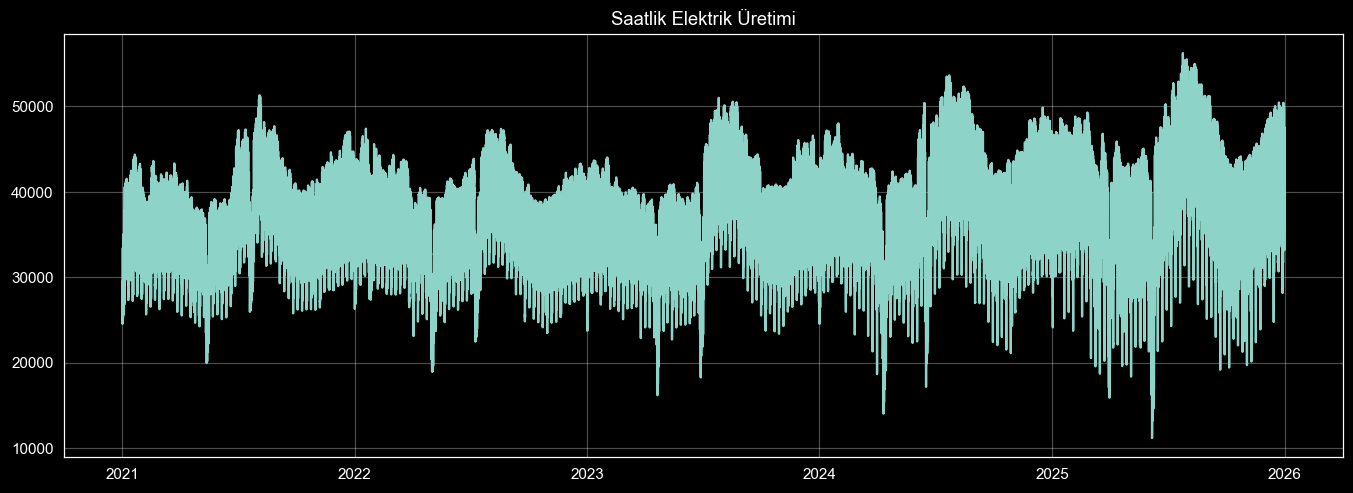

In [13]:
plt.figure(figsize=(15,5))

plt.plot(veri["uretim_mwh"])

plt.title("Saatlik Elektrik Üretimi")

plt.show()

Elektrik fiyatı

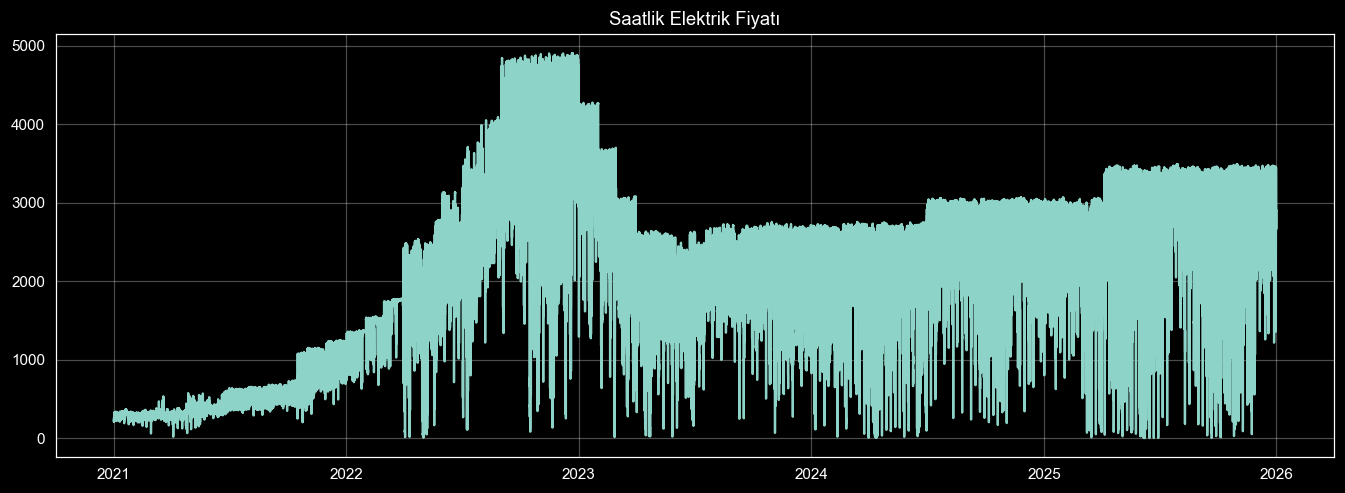

In [14]:
plt.figure(figsize=(15,5))

plt.plot(veri["fiyat_tl"])

plt.title("Saatlik Elektrik Fiyatı")

plt.show()

Saatlik Ortalama Tüketim / Fiyat Profili

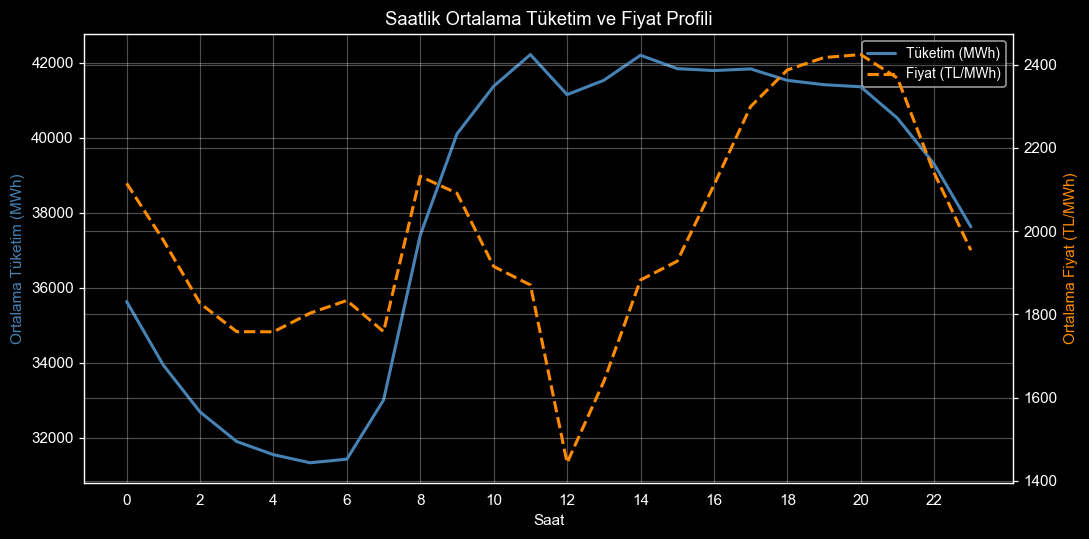

In [15]:
def saatlik_profil_fixed(veri):
    veri["hour"] = veri.index.hour
    hourly_avg = veri.groupby("hour").mean(numeric_only=True)

    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax2 = ax1.twinx()  # DÜZELTME: ikincil eksen

    ax1.plot(hourly_avg.index, hourly_avg["tuketim_mwh"],
             color="steelblue", lw=2, label="Tüketim (MWh)")
    ax2.plot(hourly_avg.index, hourly_avg["fiyat_tl"],
             color="darkorange", lw=2, ls="--", label="Fiyat (TL/MWh)")

    ax1.set_xlabel("Saat")
    ax1.set_ylabel("Ortalama Tüketim (MWh)", color="steelblue")
    ax2.set_ylabel("Ortalama Fiyat (TL/MWh)", color="darkorange")
    ax1.set_title("Saatlik Ortalama Tüketim ve Fiyat Profili")
    ax1.set_xticks(range(0, 24, 2))

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9)

    plt.tight_layout()
    plt.show()

saatlik_profil_fixed(veri)

Haftanın Günlerine Göre Analiz

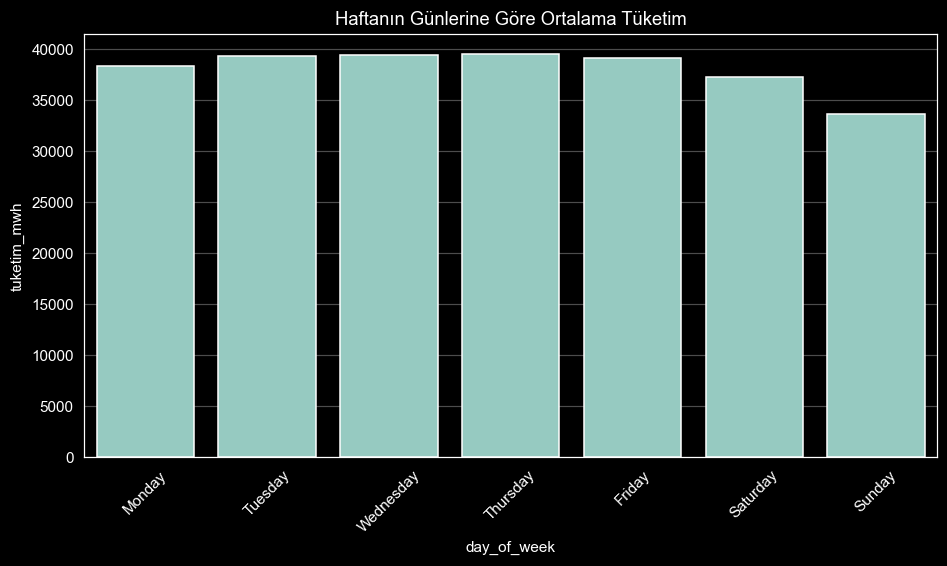

In [16]:
veri["day_of_week"] = veri.index.day_name()

weekly_avg = veri.groupby("day_of_week").mean()

order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

weekly_avg = weekly_avg.loc[order]

plt.figure(figsize=(10,5))

sns.barplot(x=weekly_avg.index,
            y=weekly_avg["tuketim_mwh"])

plt.title("Haftanın Günlerine Göre Ortalama Tüketim")
plt.xticks(rotation=45)

plt.show()

Aylara Göre Tüketim ve Fiyat

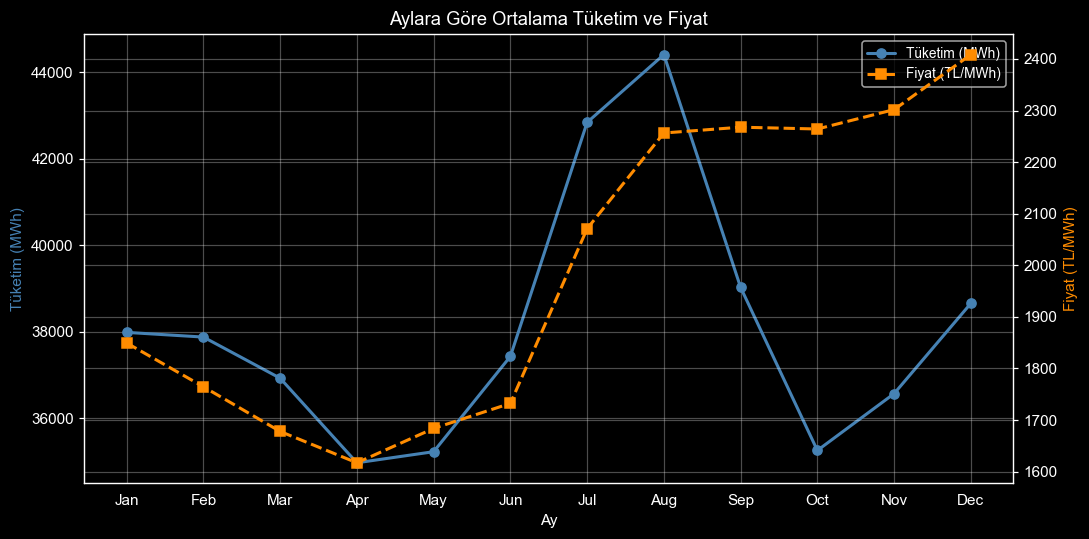

In [17]:
import calendar

veri["month"] = veri.index.month
monthly_avg = veri.groupby("month").mean(numeric_only=True)
months = [calendar.month_abbr[i] for i in monthly_avg.index]

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()   # ← İKİNCİL EKSEN: ölçek farkı çok büyük

ax1.plot(months, monthly_avg["tuketim_mwh"], marker="o",
         color="steelblue", lw=2, label="Tüketim (MWh)")
ax2.plot(months, monthly_avg["fiyat_tl"], marker="s",
         color="darkorange", lw=2, ls="--", label="Fiyat (TL/MWh)")

ax1.set_ylabel("Tüketim (MWh)", color="steelblue")
ax2.set_ylabel("Fiyat (TL/MWh)", color="darkorange")
ax1.set_xlabel("Ay")
ax1.set_title("Aylara Göre Ortalama Tüketim ve Fiyat")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9)

plt.tight_layout()
plt.show()

Isı Haritası (Saat × Gün)

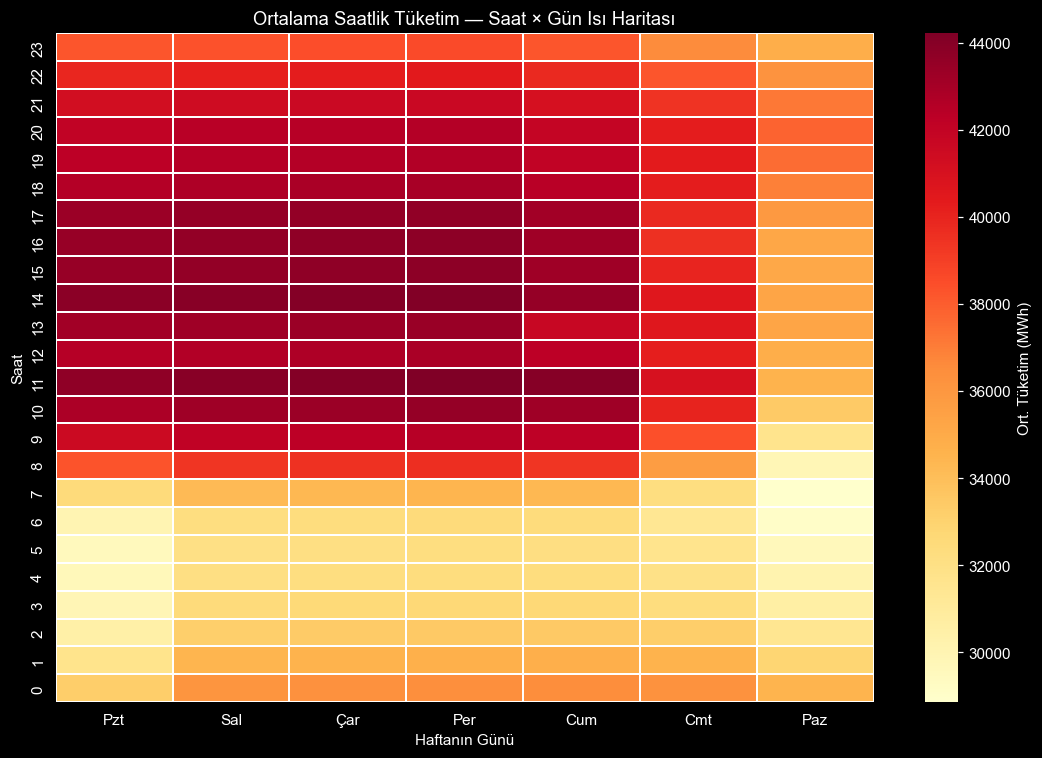

In [18]:
def plot_heatmap(veri):
    pivot_table = veri.pivot_table(
        values="tuketim_mwh",
        index=veri.index.hour,
        columns=veri.index.dayofweek,
    )
    pivot_table.columns = ["Pzt", "Sal", "Çar", "Per", "Cum", "Cmt", "Paz"]

    fig, ax = plt.subplots(figsize=(10, 7))
    sns.heatmap(
        pivot_table,
        annot=False,
        fmt=".0f",
        cmap="YlOrRd",
        linewidths=0.3,
        ax=ax,
        cbar_kws={"label": "Ort. Tüketim (MWh)"}
    )
    ax.set_title("Ortalama Saatlik Tüketim — Saat × Gün Isı Haritası", fontsize=12)
    ax.set_xlabel("Haftanın Günü")
    ax.set_ylabel("Saat")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

plot_heatmap(veri)

Fiyat vs Tüketim Scatter

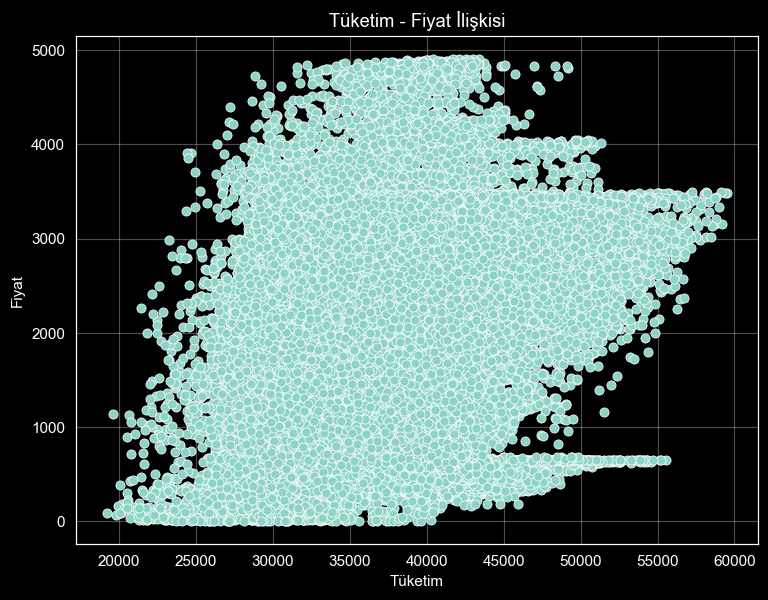

In [19]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=veri["tuketim_mwh"],
    y=veri["fiyat_tl"]
)

plt.xlabel("Tüketim")
plt.ylabel("Fiyat")

plt.title("Tüketim - Fiyat İlişkisi")

plt.show()

Sıcaklık vs Elektrik Tüketimi

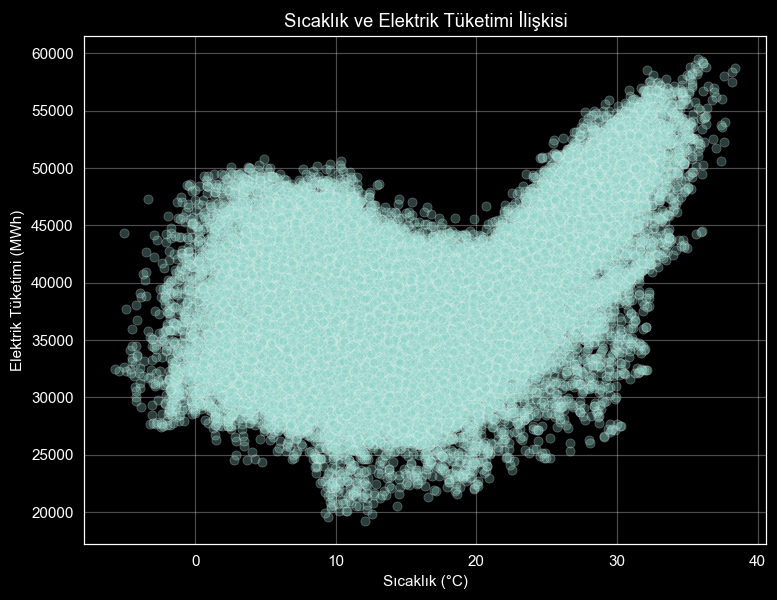

In [20]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=veri["sicaklik"],
    y=veri["tuketim_mwh"],
    alpha=0.3
)

plt.xlabel("Sıcaklık (°C)")
plt.ylabel("Elektrik Tüketimi (MWh)")
plt.title("Sıcaklık ve Elektrik Tüketimi İlişkisi")

plt.show()

Sıcaklık Gruplarına Göre Ortalama Tüketim

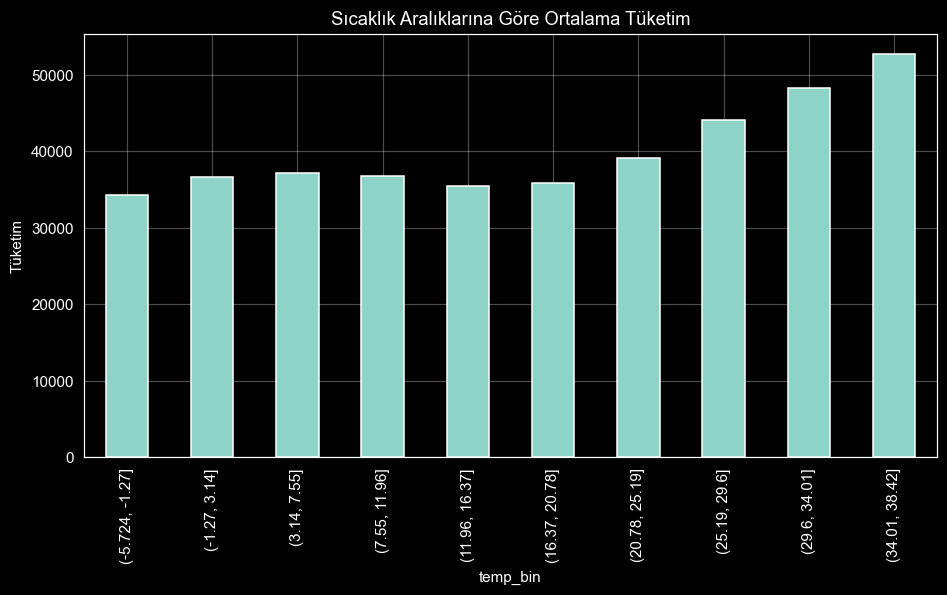

In [21]:
veri["temp_bin"] = pd.cut(
    veri["sicaklik"],
    bins=10
)

temp_consumption = veri.groupby("temp_bin")["tuketim_mwh"].mean()

plt.figure(figsize=(10,5))

temp_consumption.plot(kind="bar")

plt.title("Sıcaklık Aralıklarına Göre Ortalama Tüketim")

plt.ylabel("Tüketim")

plt.show()

Rolling trend

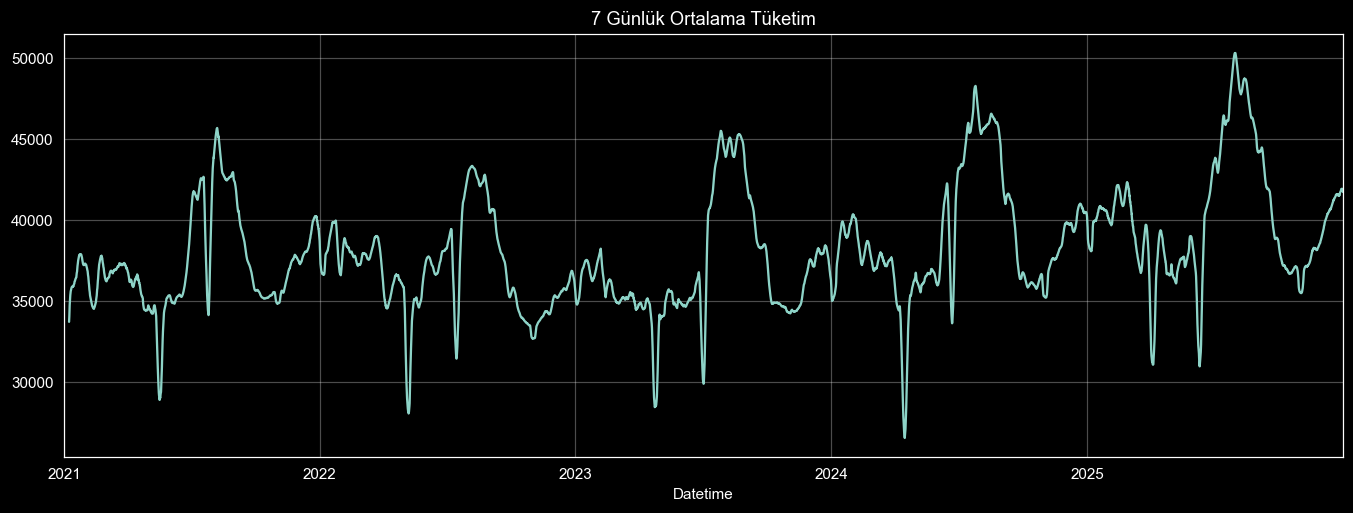

In [22]:
veri["tuketim_mwh"].rolling(24*7).mean().plot(figsize=(15,5))
plt.title("7 Günlük Ortalama Tüketim")
plt.show()

Özellik Dağılımı (Distribution)

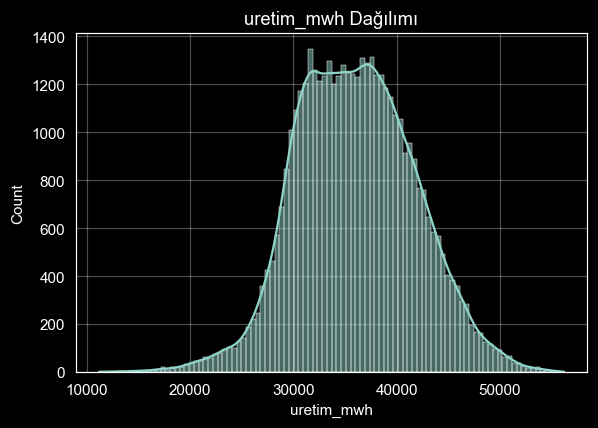

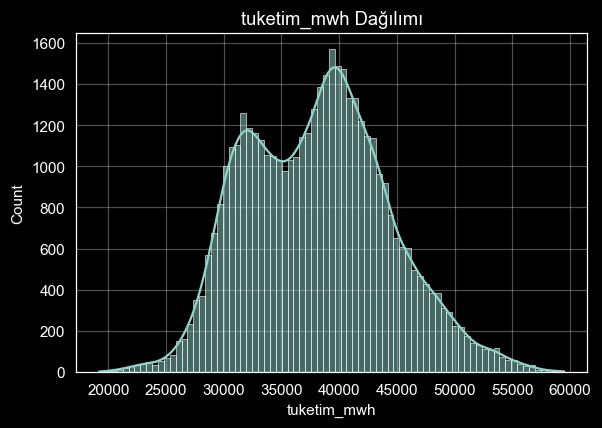

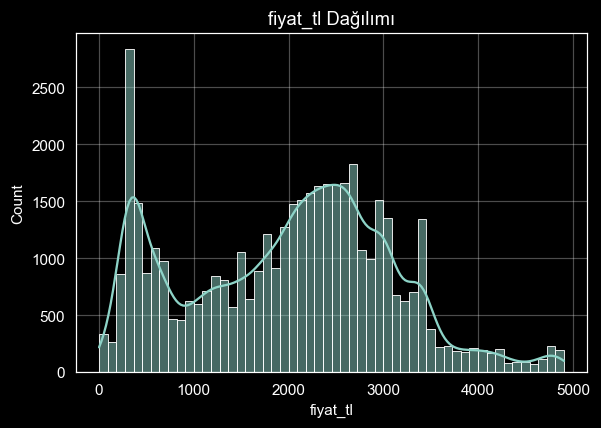

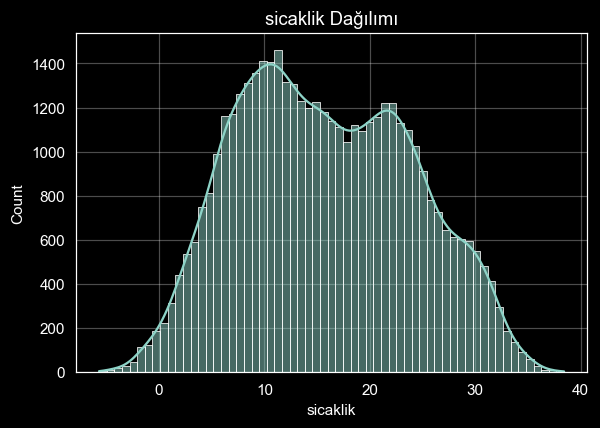

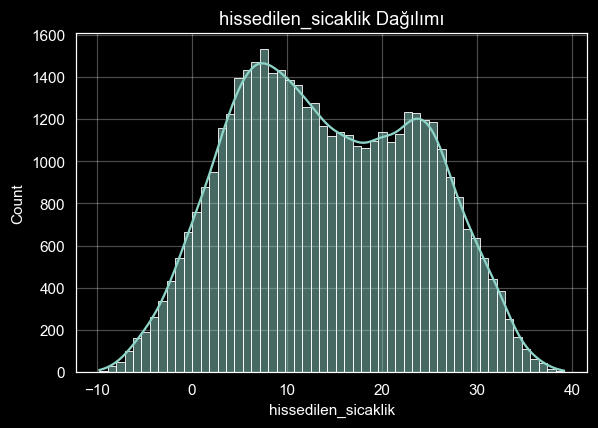

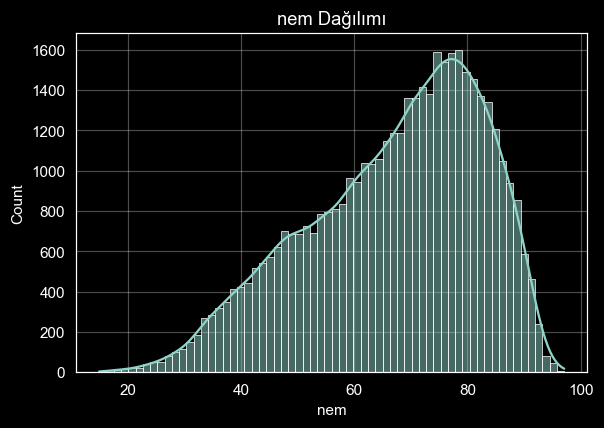

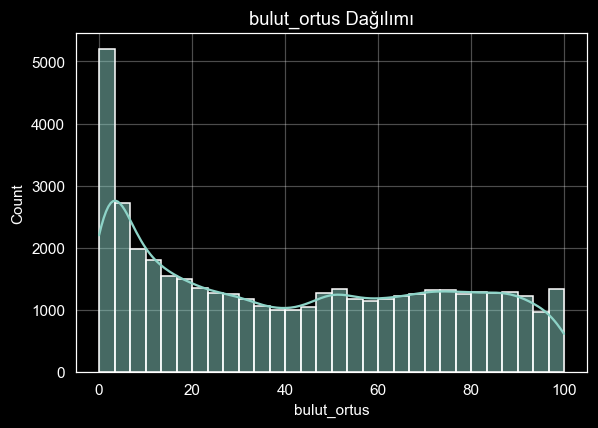

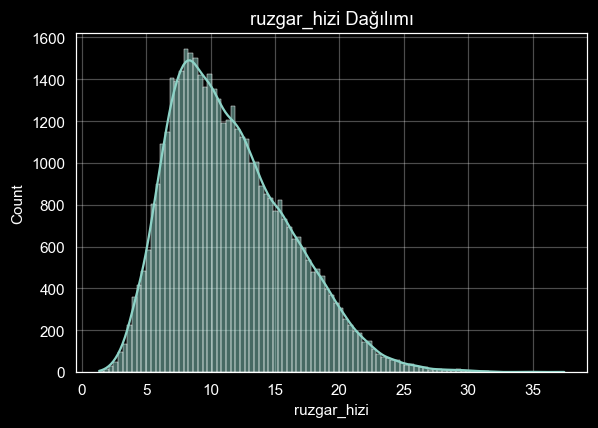

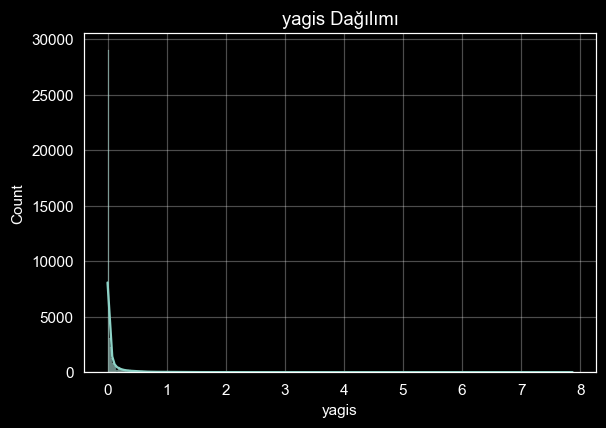

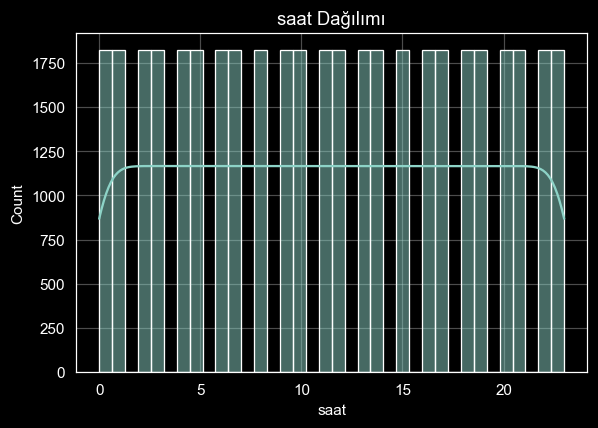

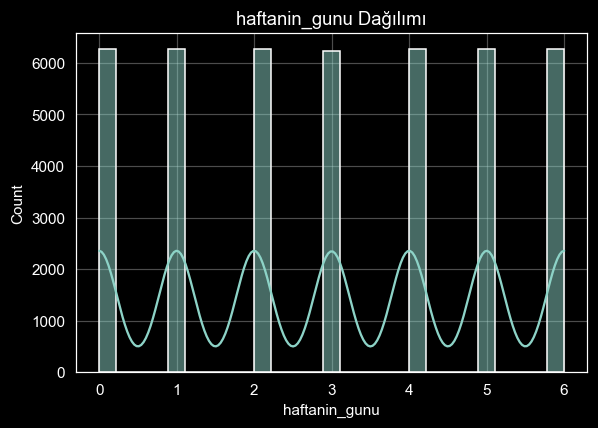

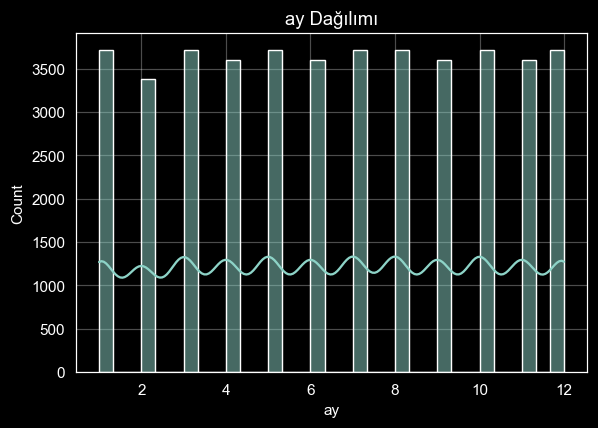

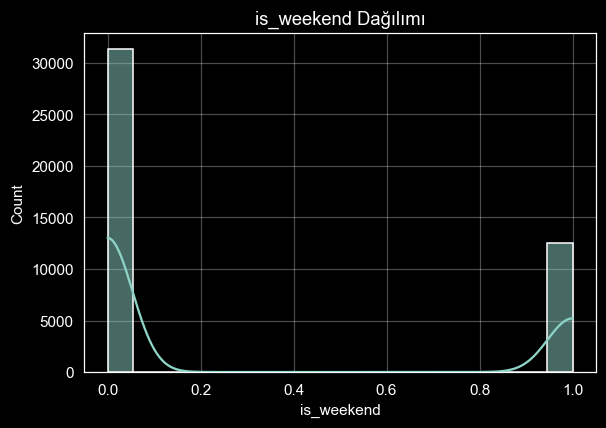

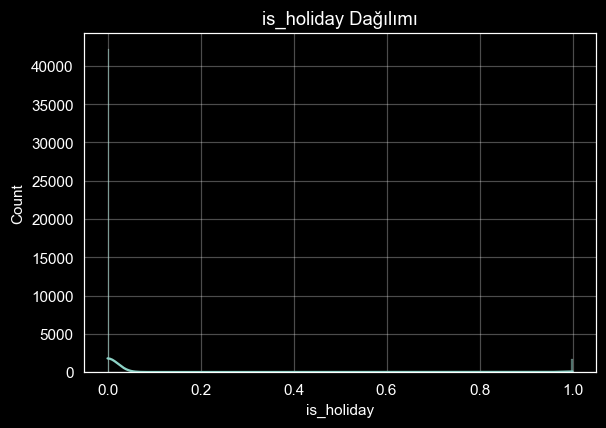

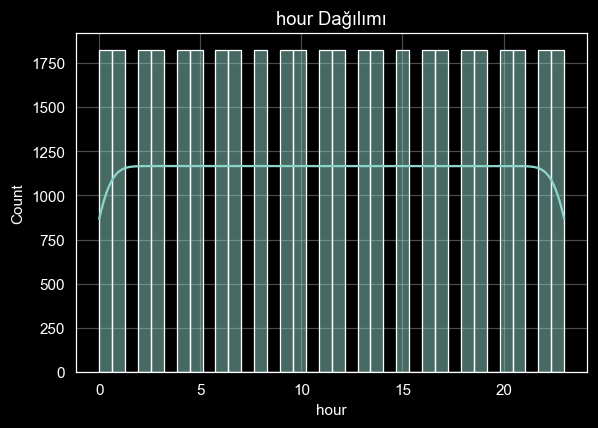

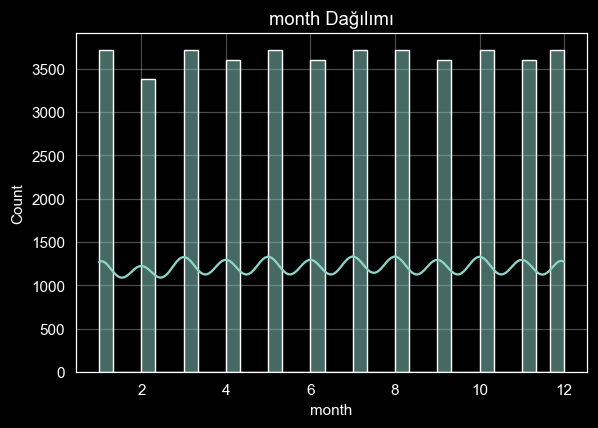

In [23]:
numeric_cols = veri.select_dtypes(include="number").columns.tolist()

for col in numeric_cols:

    plt.figure(figsize=(6,4))
    
    sns.histplot(veri[col],
                 kde=True)
    
    plt.title(f"{col} Dağılımı")
    
    plt.show()

Korelasyon Analizi

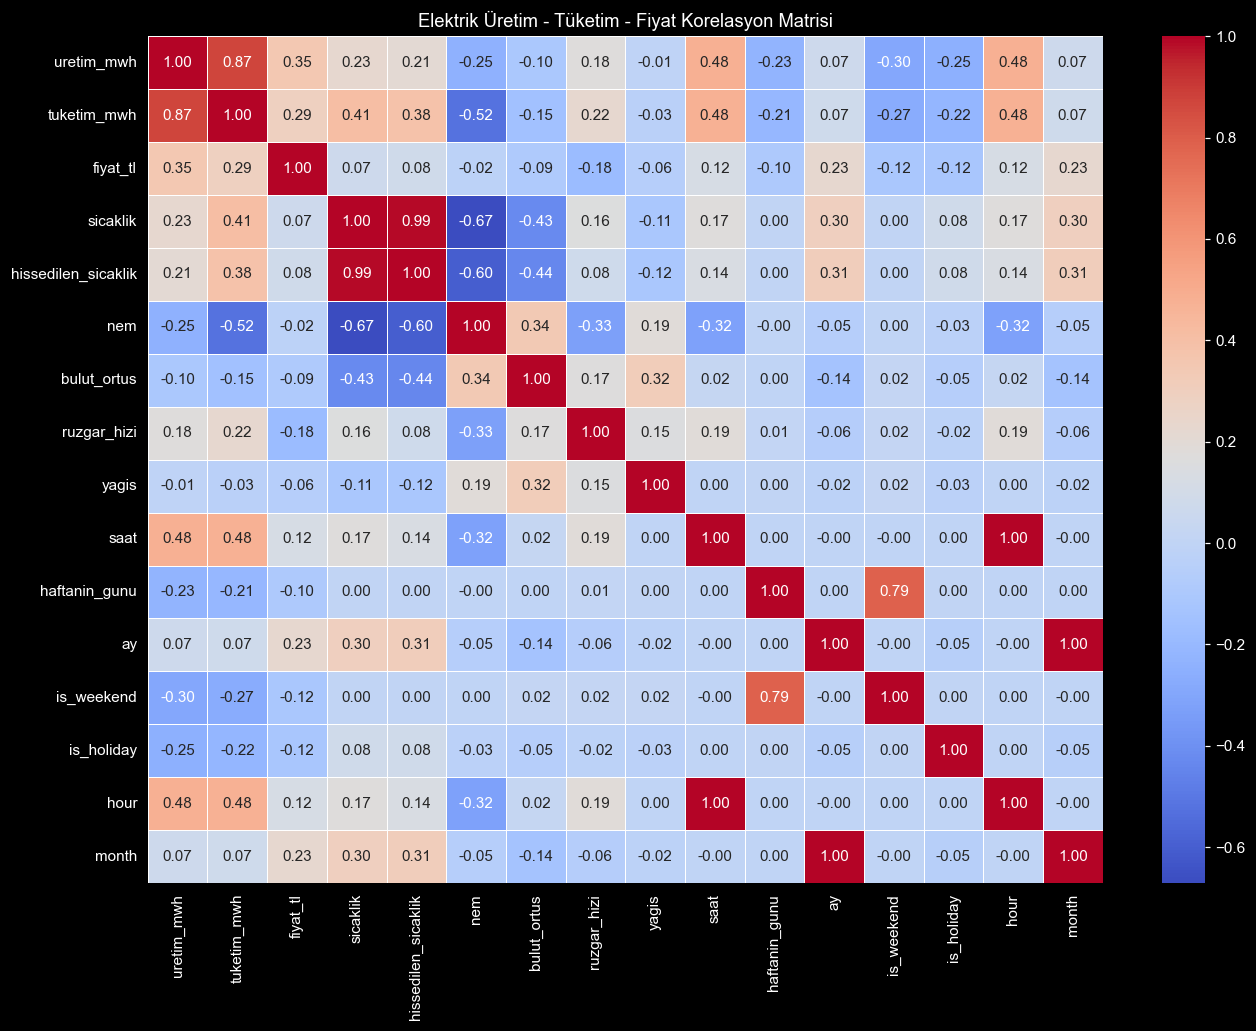

In [24]:
corr_matrix = veri.select_dtypes(include="number").corr()

plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Elektrik Üretim - Tüketim - Fiyat Korelasyon Matrisi")

plt.show()

Stationarity Testleri

In [25]:
def durağanlik_testi_v2(veri):
    from statsmodels.tsa.stattools import adfuller, kpss

    kolonlar = {
        "tuketim_mwh": "Tüketim",
        "fiyat_tl":    "Fiyat",
        "uretim_mwh":  "Üretim",
    }
    sonuclar = []

    print("=" * 60)
    print("DURAĞANLIK TESTLERİ (GELİŞTİRİLMİŞ)")
    print("=" * 60)

    for col, label in kolonlar.items():
        seri = veri[col].dropna()

        adf_stat, adf_p, adf_lag, *_ = adfuller(seri, autolag="AIC")
        kpss_stat, kpss_p, kpss_lag, _ = kpss(seri, regression="c", nlags="auto")

        seri_d1 = seri.diff().dropna()
        adf_d1_stat, adf_d1_p, *_ = adfuller(seri_d1, autolag="AIC")

        adf_duragan  = adf_p  < 0.05
        kpss_duragan = kpss_p > 0.05   # KPSS H0 = durağan; yüksek p → ret edilmez

        # DÜZELTME: 4 durum yorumu
        if adf_duragan and kpss_duragan:
            yorum = "Durağan ✓ (ADF ✓, KPSS ✓)"
            sarimax_d = 0
        elif adf_duragan and not kpss_duragan:
            yorum = "Trend-Durağan (ADF ✓, KPSS ✗ — uzun hafıza veya trend var)"
            sarimax_d = 1   # Güvenli taraf: fark al
        elif not adf_duragan and kpss_duragan:
            yorum = "Fark-Durağan (ADF ✗, KPSS ✓ — d=1 yeterli)"
            sarimax_d = 1
        else:
            yorum = "Durağan DEĞİL ✗ (ADF ✗, KPSS ✗ — d=1 veya 2 dene)"
            sarimax_d = 1

        print(f"\n{'─'*50}")
        print(f"{label}")
        print(f"  ADF: stat={adf_stat:.3f}  p={adf_p:.4f}  lag={adf_lag}")
        print(f"  KPSS: stat={kpss_stat:.3f}  p={kpss_p:.4f}")
        print(f"  → {yorum}")
        print(f"  ADF (d=1): stat={adf_d1_stat:.3f}  p={adf_d1_p:.4f}  "
              f"→ {'Durağan ✓' if adf_d1_p < 0.05 else 'Durağan Değil ✗'}")
        print(f"  ★ SARIMAX önerilen d = {sarimax_d}")

        sonuclar.append({
            "Değişken": label, "ADF_p": round(adf_p, 4),
            "KPSS_p": round(kpss_p, 4), "Yorum": yorum, "d": sarimax_d
        })

    print(f"\n{'─'*50}")
    print("ÖZET:")
    print(pd.DataFrame(sonuclar)[["Değişken", "ADF_p", "KPSS_p", "d", "Yorum"]]
          .to_string(index=False))

    return pd.DataFrame(sonuclar)

durağanlik_testi_v2(veri)

DURAĞANLIK TESTLERİ (GELİŞTİRİLMİŞ)

──────────────────────────────────────────────────
Tüketim
  ADF: stat=-12.181  p=0.0000  lag=54
  KPSS: stat=4.876  p=0.0100
  → Trend-Durağan ⚠️  (ADF ✓, KPSS ✗ — uzun hafıza veya trend var)
  ADF (d=1): stat=-35.177  p=0.0000  → Durağan ✓
  ★ SARIMAX önerilen d = 1

──────────────────────────────────────────────────
Fiyat
  ADF: stat=-6.266  p=0.0000  lag=55
  KPSS: stat=15.892  p=0.0100
  → Trend-Durağan ⚠️  (ADF ✓, KPSS ✗ — uzun hafıza veya trend var)
  ADF (d=1): stat=-39.423  p=0.0000  → Durağan ✓
  ★ SARIMAX önerilen d = 1

──────────────────────────────────────────────────
Üretim
  ADF: stat=-13.600  p=0.0000  lag=55
  KPSS: stat=1.056  p=0.0100
  → Trend-Durağan ⚠️  (ADF ✓, KPSS ✗ — uzun hafıza veya trend var)
  ADF (d=1): stat=-34.991  p=0.0000  → Durağan ✓
  ★ SARIMAX önerilen d = 1

──────────────────────────────────────────────────
ÖZET:
Değişken  ADF_p  KPSS_p  d                                                          Yorum
 Tüketim 

,Değişken,ADF_p,KPSS_p,Yorum,d
0,Tüketim,0.0,0.01,"Trend-Durağan ⚠️ (ADF ✓, KPSS ✗ — uzun hafıza...",1
1,Fiyat,0.0,0.01,"Trend-Durağan ⚠️ (ADF ✓, KPSS ✗ — uzun hafıza...",1
2,Üretim,0.0,0.01,"Trend-Durağan ⚠️ (ADF ✓, KPSS ✗ — uzun hafıza...",1


ACF / PACF Analizi

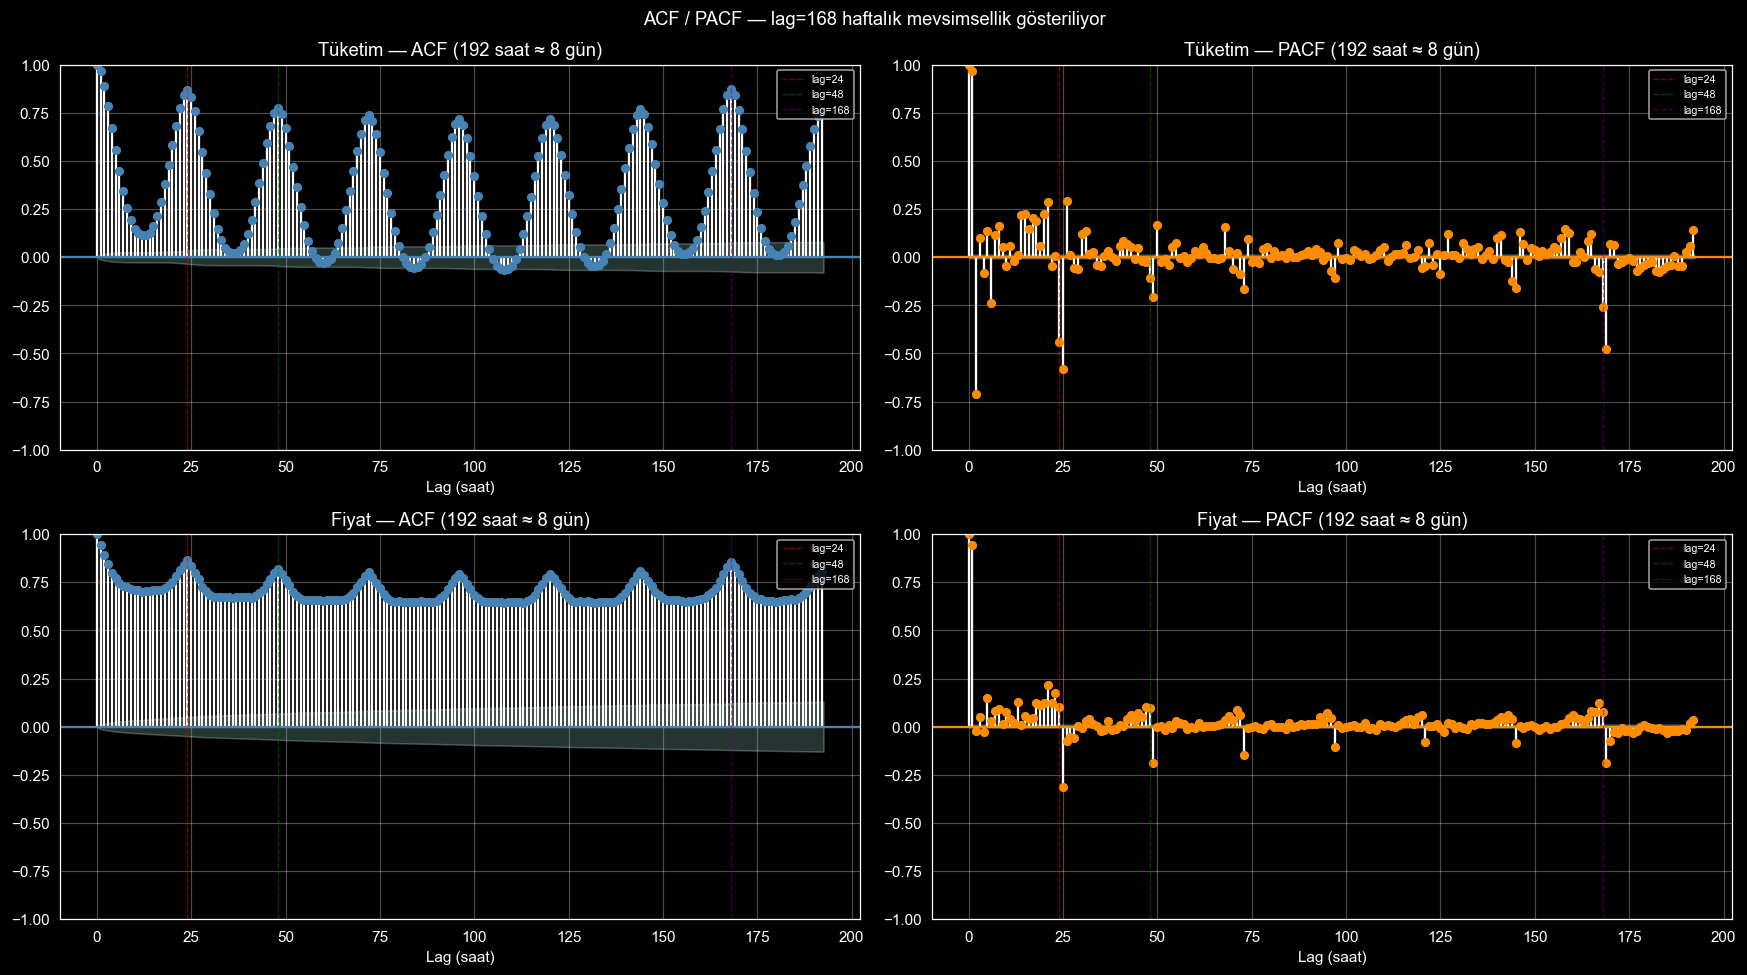


Saatlik otokorelasyon değerleri:

  Tüketim:
    lag_   1: r = +0.967  ★ Çok güçlü
    lag_   2: r = +0.888  ★ Çok güçlü
    lag_  24: r = +0.868  ★ Çok güçlü
    lag_  48: r = +0.777  ✓ Güçlü
    lag_ 168: r = +0.879  ★ Çok güçlü

  Fiyat:
    lag_   1: r = +0.945  ★ Çok güçlü
    lag_   2: r = +0.892  ★ Çok güçlü
    lag_  24: r = +0.864  ★ Çok güçlü
    lag_  48: r = +0.820  ★ Çok güçlü
    lag_ 168: r = +0.863  ★ Çok güçlü


In [26]:
def plot_acf_pacf_fixed(veri):
    fig, axes = plt.subplots(2, 2, figsize=(16, 9))

    for row, (col, label) in enumerate([
        ("tuketim_mwh", "Tüketim"),
        ("fiyat_tl",    "Fiyat")
    ]):
        seri = veri[col].dropna()

        # DÜZELTME: lags=72 → lags=192 (8 gün → haftalık lag=168 görünür)
        plot_acf(seri,  lags=192, ax=axes[row, 0],
                 title=f"{label} — ACF (192 saat ≈ 8 gün)",
                 alpha=0.05, color="steelblue")
        plot_pacf(seri, lags=192, ax=axes[row, 1],
                  title=f"{label} — PACF (192 saat ≈ 8 gün)",
                  alpha=0.05, color="darkorange", method="ywm")

        # DÜZELTME: lag <= 72 koşulu kaldırıldı → tüm kritik lag'lar çizilir
        for ax in [axes[row, 0], axes[row, 1]]:
            for lag, color in [(24, "red"), (48, "green"), (168, "purple")]:
                ax.axvline(lag, color=color, ls="--", alpha=0.5, lw=0.9,
                           label=f"lag={lag}")
            ax.set_xlabel("Lag (saat)")
            ax.legend(fontsize=7, loc="upper right")

    plt.suptitle("ACF / PACF — lag=168 haftalık mevsimsellik gösteriliyor", fontsize=12)
    plt.tight_layout()
    plt.show()

plot_acf_pacf_fixed(veri)

# ── Günlük (24h) ve haftalık (168h) korelasyonu raporla ────────────────────
print("\nSaatlik otokorelasyon değerleri:")
for col, label in [("tuketim_mwh", "Tüketim"), ("fiyat_tl", "Fiyat")]:
    seri = veri[col].dropna()
    print(f"\n  {label}:")
    for lag in [1, 2, 24, 48, 168]:
        r = seri.autocorr(lag=lag)
        yorum = "Çok güçlü" if abs(r)>0.8 else ("✓ Güçlü" if abs(r)>0.5 else "· Zayıf")
        print(f"    lag_{lag:4d}: r = {r:+.3f}  {yorum}")

Çapraz Korelasyon Analizi


Tüketim: → lag=48 saatte güçlü etki — lag_48 özelliği ekle

Fiyat: → Maksimum r=0.147 < 0.2 eşiği — sıcaklığın fiyat üzerinde doğrudan lag etkisi zayıf


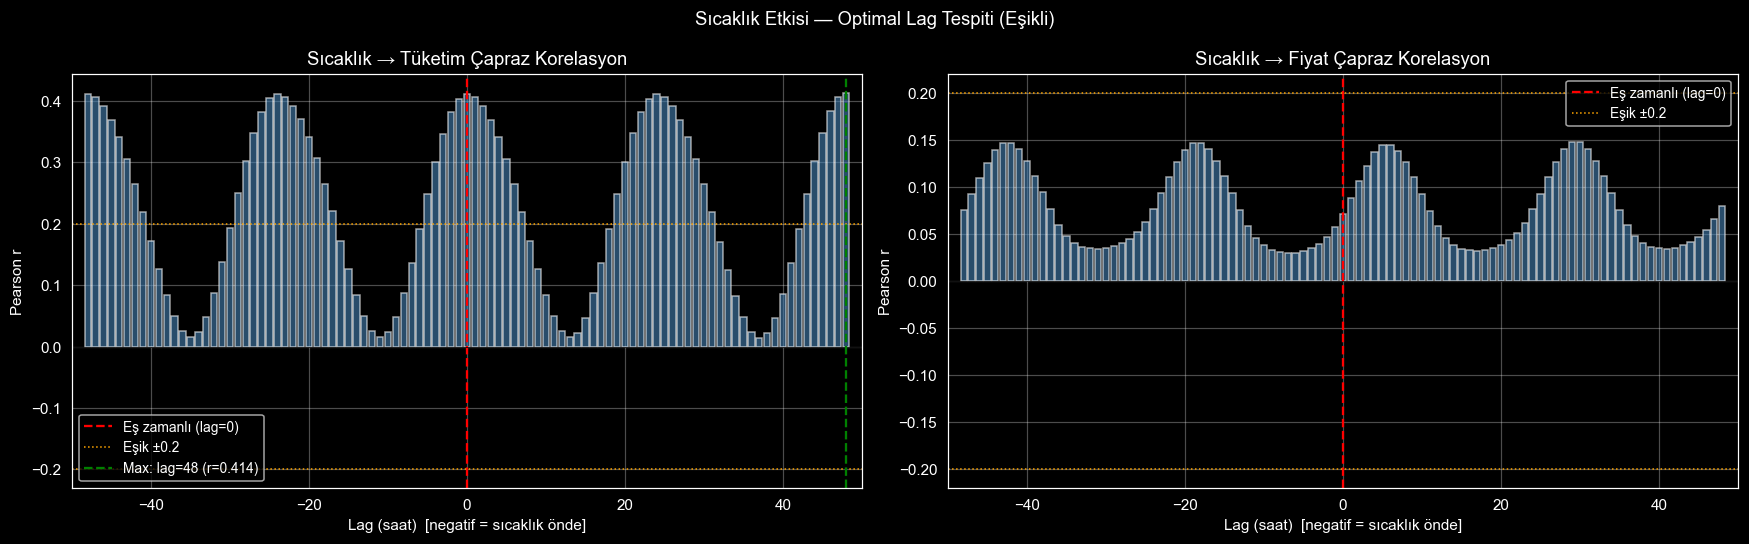


Hava Değişkeni → Tüketim/Fiyat Anlık Korelasyonu:
Değişken                     → Tüketim    → Fiyat
──────────────────────────────────────────────────
  sicaklik                    +0.411     +0.072
  hissedilen_sicaklik         +0.380     +0.082
  nem                         -0.524     -0.023
  ruzgar_hizi                 +0.225     -0.183
  bulut_ortus                 -0.154     -0.088
  yagis                       -0.032     -0.057


In [27]:
def capraz_korelasyon_fixed(veri):
    lag_aralik = range(-48, 49)
    ANLAMLI_ESIK = 0.20  # |r| < bu eşik → anlamsız

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    for ax, (hedef, label) in zip(axes, [
        ("tuketim_mwh", "Tüketim"),
        ("fiyat_tl",    "Fiyat")
    ]):
        ccf_vals = [
            veri[hedef].corr(veri["sicaklik"].shift(lag))
            for lag in lag_aralik
        ]
        lag_listesi = list(lag_aralik)

        ax.bar(lag_listesi, ccf_vals, color="steelblue", alpha=0.6, width=0.8)
        ax.axvline(0,  color="red",   ls="--", lw=1.5, label="Eş zamanlı (lag=0)")
        ax.axhline(0,  color="black", ls="-",  lw=0.5)
        ax.axhline( ANLAMLI_ESIK, color="orange", ls=":", lw=1, label=f"Eşik ±{ANLAMLI_ESIK}")
        ax.axhline(-ANLAMLI_ESIK, color="orange", ls=":", lw=1)

        max_r    = max(ccf_vals, key=abs)
        max_lag  = lag_listesi[ccf_vals.index(max_r)]

        if abs(max_r) >= ANLAMLI_ESIK:
            ax.axvline(max_lag, color="green", ls="--", lw=1.5,
                       label=f"Max: lag={max_lag} (r={max_r:.3f})")
            yorum = (f"→ lag={max_lag} saatte güçlü etki — "
                     f"{'lag_' + str(abs(max_lag)) + ' özelliği ekle' if max_lag != 0 else 't-anı yeterli'}")
        else:
            # DÜZELTME: Düşük korelasyon "anlamsız" olarak işaretleniyor
            yorum = (f"Maksimum r={max_r:.3f} < {ANLAMLI_ESIK} eşiği — "
                     f"sıcaklığın {label.lower()} üzerinde doğrudan lag etkisi zayıf")

        ax.set_title(f"Sıcaklık → {label} Çapraz Korelasyon")
        ax.set_xlabel("Lag (saat)  [negatif = sıcaklık önde]")
        ax.set_ylabel("Pearson r")
        ax.legend(fontsize=9)
        ax.set_xlim(-50, 50)

        print(f"\n{label}: {yorum}")

    plt.suptitle("Sıcaklık Etkisi — Optimal Lag Tespiti (Eşikli)", fontsize=12)
    plt.tight_layout()
    plt.show()

capraz_korelasyon_fixed(veri)

# ── Diğer hava değişkenleri korelasyon özeti ────────────────────────────────
hava_cols = ["sicaklik", "hissedilen_sicaklik", "nem",
             "ruzgar_hizi", "bulut_ortus", "yagis"]

print("\nHava Değişkeni → Tüketim/Fiyat Anlık Korelasyonu:")
print(f"{'Değişken':<25} {'→ Tüketim':>12} {'→ Fiyat':>10}")
print("─" * 50)
for col in hava_cols:
    r_t = veri["tuketim_mwh"].corr(veri[col])
    r_f = veri["fiyat_tl"].corr(veri[col])
    print(f"  {col:<23} {r_t:>+10.3f} {r_f:>+10.3f}")

Yıllık Trend ve Yapısal Kırılma

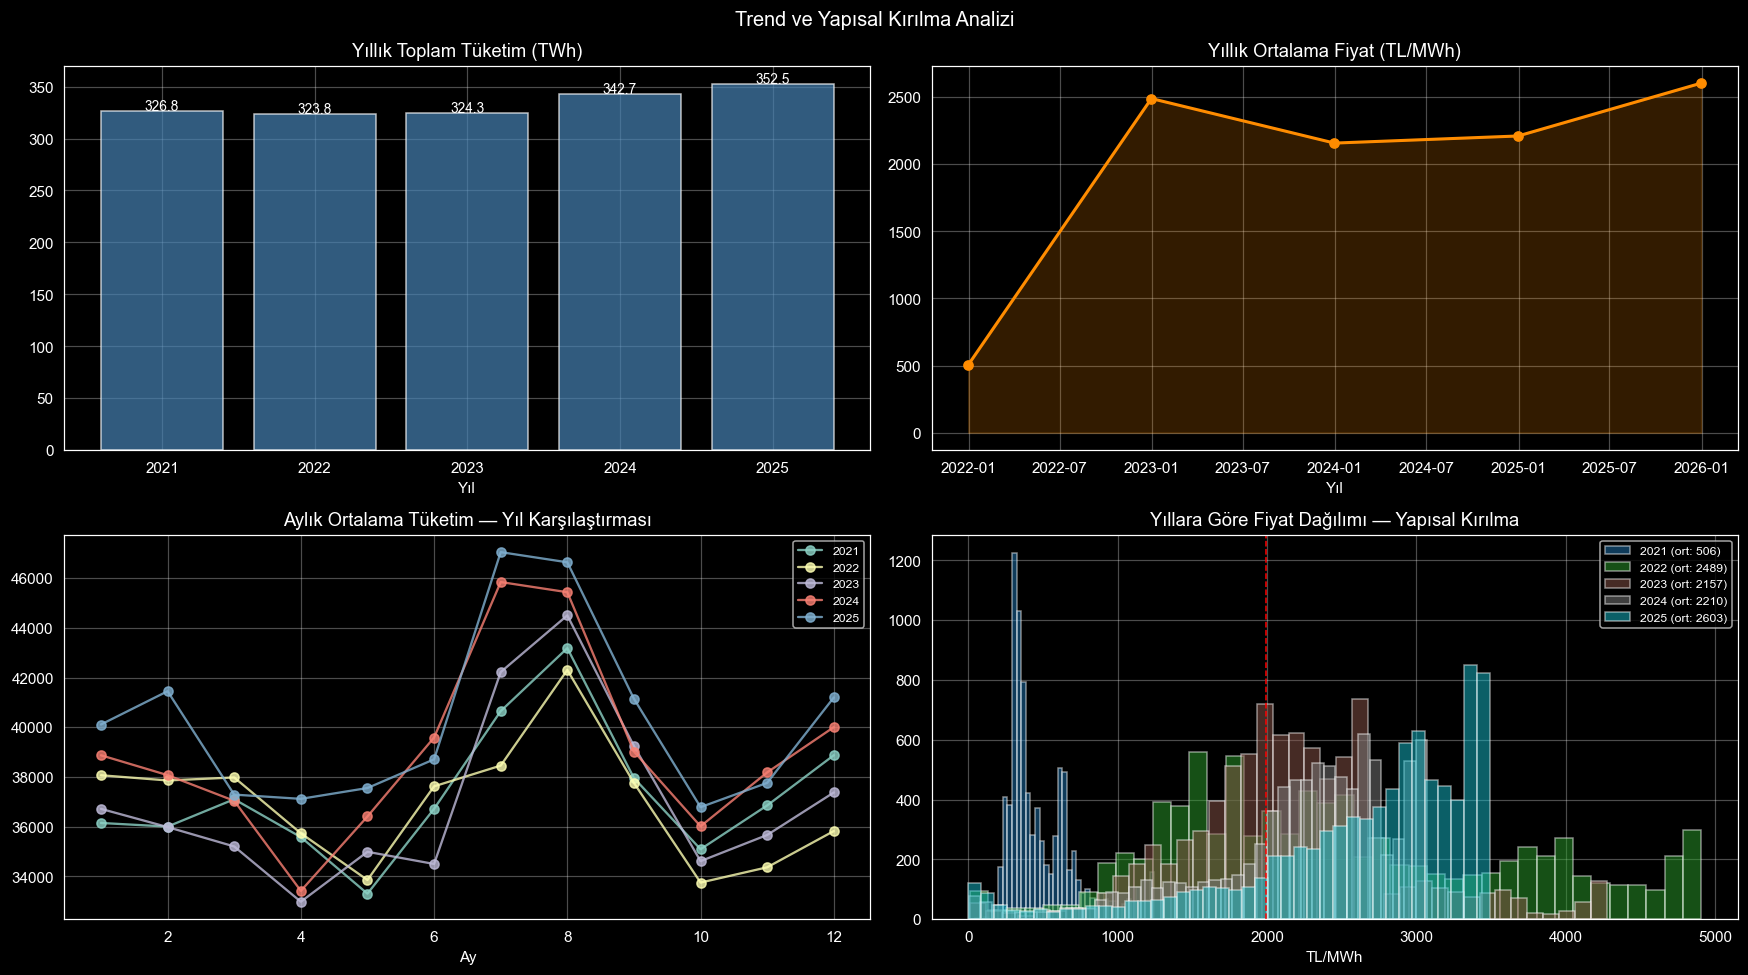


Yıllık İstatistikler:
Yıl      Ort.Tüketim(MWh)   Ort.Fiyat(TL)    Fiyat Std
───────────────────────────────────────────────────────
2021                37305           505.9        248.3
2022                36965          2488.8       1170.5
2023                37023          2157.0        713.0
2024                39013          2209.9        667.6
2025                40241          2603.4        809.4

→ 2021 fiyat ortalaması diğer yılların ~5× altında → min_year=2022 doğru.


In [28]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9))

# ── 1. Yıllık toplam tüketim trendi ─────────────────────────────────────────
yillik_tuketim = veri["tuketim_mwh"].resample("YE").sum() / 1e6  # TWh
axes[0,0].bar(yillik_tuketim.index.year, yillik_tuketim.values,
              color="steelblue", alpha=0.7, edgecolor="white")
for x, y in zip(yillik_tuketim.index.year, yillik_tuketim.values):
    axes[0,0].text(x, y+0.5, f"{y:.1f}", ha="center", fontsize=9)
axes[0,0].set_title("Yıllık Toplam Tüketim (TWh)")
axes[0,0].set_xlabel("Yıl")

# ── 2. Yıllık ortalama fiyat trendi ─────────────────────────────────────────
yillik_fiyat = veri["fiyat_tl"].resample("YE").mean()
axes[0,1].plot(yillik_fiyat.index, yillik_fiyat.values,
               marker="o", lw=2, color="darkorange")
axes[0,1].fill_between(yillik_fiyat.index, yillik_fiyat.values,
                        alpha=0.2, color="darkorange")
axes[0,1].set_title("Yıllık Ortalama Fiyat (TL/MWh)")
axes[0,1].set_xlabel("Yıl")

# ── 3. Aylık tüketim — mevsimsellik yıllara göre değişiyor mu? ───────────────
aylik = veri["tuketim_mwh"].resample("ME").mean()
for yil in veri.index.year.unique():
    dilim = aylik[aylik.index.year == yil]
    axes[1,0].plot(dilim.index.month, dilim.values,
                   marker="o", lw=1.5, label=str(yil), alpha=0.8)
axes[1,0].set_title("Aylık Ortalama Tüketim — Yıl Karşılaştırması")
axes[1,0].set_xlabel("Ay")
axes[1,0].legend(fontsize=8)

# ── 4. Fiyat dağılımı yıllara göre (2021 kırılması) ──────────────────────────
yillar = sorted(veri.index.year.unique())
renkler = plt.cm.tab10(np.linspace(0, 1, len(yillar)))
for yil, renk in zip(yillar, renkler):
    dilim = veri.loc[veri.index.year == yil, "fiyat_tl"]
    axes[1,1].hist(dilim, bins=40, alpha=0.5,
                   label=f"{yil} (ort: {dilim.mean():.0f})",
                   color=renk, edgecolor="white")
axes[1,1].set_title("Yıllara Göre Fiyat Dağılımı — Yapısal Kırılma")
axes[1,1].set_xlabel("TL/MWh")
axes[1,1].legend(fontsize=8)
axes[1,1].axvline(veri["fiyat_tl"].mean(), color="red", ls="--", lw=1)

plt.suptitle("Trend ve Yapısal Kırılma Analizi", fontsize=13)
plt.tight_layout()
plt.show()

# ── Sayısal özet ─────────────────────────────────────────────────────────────
print("\nYıllık İstatistikler:")
print(f"{'Yıl':<6} {'Ort.Tüketim(MWh)':>18} {'Ort.Fiyat(TL)':>15} {'Fiyat Std':>12}")
print("─" * 55)
for yil in yillar:
    dilim = veri[veri.index.year == yil]
    print(f"{yil:<6} {dilim['tuketim_mwh'].mean():>18.0f} "
          f"{dilim['fiyat_tl'].mean():>15.1f} "
          f"{dilim['fiyat_tl'].std():>12.1f}")

print("\n→ 2021 fiyat ortalaması diğer yılların ~5× altında → min_year=2022 doğru.")

In [29]:
def fiyat_anomali_sutunlari_ekle(veri):
    """
    is_price_spike: fiyat > 95. yüzdelik → aşırı fiyat saatleri
    is_price_dip  : fiyat < 5. yüzdelik  → çok düşük / negatif fiyat saatleri
    """
    p95 = veri["fiyat_tl"].quantile(0.95)
    p05 = veri["fiyat_tl"].quantile(0.05)

    veri["is_price_spike"] = (veri["fiyat_tl"] > p95).astype(int)
    veri["is_price_dip"]   = (veri["fiyat_tl"] < p05).astype(int)

    print(f"Fiyat eşikleri: P5={p05:.1f} TL/MWh  |  P95={p95:.1f} TL/MWh")
    print(f"is_price_spike: {veri['is_price_spike'].sum()} saat "
          f"(%{veri['is_price_spike'].mean()*100:.1f})")
    print(f"is_price_dip  : {veri['is_price_dip'].sum()} saat "
          f"(%{veri['is_price_dip'].mean()*100:.1f})")
    return veri

# Geçici EDA kolonlarını temizle

veri = fiyat_anomali_sutunlari_ekle(veri)

eda_cols = ["hour", "day_of_week", "month", "temp_bin"]
veri_temiz = veri.drop(columns=[c for c in eda_cols if c in veri.columns])

print("Son veri seti kolonları:")
print(veri_temiz.columns.tolist())
print(f"\nBoyut: {veri_temiz.shape}")
print(f"\nNaN kontrolü:")
print(veri_temiz.isnull().sum())

# Model pipeline'ına uygun dosya adıyla kaydet
veri_temiz.to_csv("birlesik_veri.csv", index_label="Datetime",
                  index=True, encoding="utf-8-sig")
print("\n✓ birlesik_veri.csv kaydedildi — 2 yeni sütun eklendi:")
print("  is_price_spike  (fiyat > %95 eşik)")
print("  is_price_dip    (fiyat < %5 eşik)")

Fiyat eşikleri: P5=308.4 TL/MWh  |  P95=3649.3 TL/MWh
is_price_spike: 2192 saat (%5.0)
is_price_dip  : 2192 saat (%5.0)
Son veri seti kolonları:
['uretim_mwh', 'tuketim_mwh', 'fiyat_tl', 'sicaklik', 'hissedilen_sicaklik', 'nem', 'bulut_ortus', 'ruzgar_hizi', 'yagis', 'saat', 'haftanin_gunu', 'ay', 'is_weekend', 'is_holiday', 'is_price_spike', 'is_price_dip']

Boyut: (43824, 16)

NaN kontrolü:
uretim_mwh             0
tuketim_mwh            0
fiyat_tl               0
sicaklik               0
hissedilen_sicaklik    0
nem                    0
bulut_ortus            0
ruzgar_hizi            0
yagis                  0
saat                   0
haftanin_gunu          0
ay                     0
is_weekend             0
is_holiday             0
is_price_spike         0
is_price_dip           0
dtype: int64

✓ birlesik_veri.csv kaydedildi — 2 yeni sütun eklendi:
  is_price_spike  (fiyat > %95 eşik)
  is_price_dip    (fiyat < %5 eşik)
